In [1]:
# %matplotlib widget
import scipy
import numpy as np
import matplotlib.pyplot as plt
import symengine
from astropy import units as u
from astropy import constants as const
import pandas as pd
from astropy.units import Quantity
from astropy.visualization import quantity_support
from mpl_toolkits.mplot3d import Axes3D 
import mpl_toolkits.mplot3d as m3d
quantity_support()


<astropy.visualization.units.quantity_support.<locals>.MplQuantityConverter at 0x76f7009a34d0>

### Solver Definitions

In [2]:

def _find_unknown(kwargs):
    """Find the single argument set to None."""
    unknowns = [k for k, v in kwargs.items() if v is None]
    if len(unknowns) != 1:
        raise ValueError("Exactly one argument must be None")
    return unknowns[0]


def _strip_units(kwargs):
    """
    Separate numerical values and units.
    """
    values = {}
    units = {}

    for k, v in kwargs.items():
        if isinstance(v, Quantity):
            values[k] = v.value
            units[k] = v.unit
        else:
            values[k] = v
            units[k] = None

    return values, units

def auto_bracket(g, unit, scale=None, max_expand=20):
    """
    Automatically find a bracket [a, b] such that g(a) * g(b) < 0.
    g must take floats and return floats.
    """

    if scale is None:
        scale = 1.0

    x0 = scale
    f0 = g(x0)

    if f0 == 0:
        return x0, x0

    for n in range(max_expand):
        factor = 10**n

        a = -factor * x0
        b =  factor * x0

        fa = g(a)
        fb = g(b)

        if fa == 0:
            return a, a
        if fb == 0:
            return b, b

        if fa * fb < 0:
            return a, b

    raise RuntimeError(
        "Failed to bracket root automatically. "
        "Function may not cross zero."
    )


def solve_quantity(f, bracket=None, x0=None, **kwargs):
    """
    Solve f(...) = 0 for the argument set to None.
    Preserves astropy units.
    """

    # Identify unknown
    unk = _find_unknown(kwargs)

    # Infer unit of unknown
    unk_unit = None
    if isinstance(bracket, u.Quantity):
        unk_unit = bracket.unit
    elif isinstance(x0, u.Quantity):
        unk_unit = x0.unit
    else:
        # Try to infer from other arguments (rare, but possible)
        for v in kwargs.values():
            if isinstance(v, u.Quantity):
                unk_unit = v.unit
                break

    if unk_unit is None:
        raise ValueError(
            f"Cannot infer units for unknown '{unk}'. "
            "Provide bracket or x0 with units."
        )

    # Build scalar function for solver
    def g(x):
        local_kwargs = dict(kwargs)
        local_kwargs[unk] = x * unk_unit
        res = f(**local_kwargs)

        if not isinstance(res, u.Quantity):
            raise TypeError("Constraint must return an astropy Quantity")

        # Strip units *without* scaling
        return res.value

    # Solve
    if bracket is not None:
        if isinstance(bracket, u.Quantity):
            bracket = bracket.to(unk_unit).value
        sol = scipy.optimize.brentq(g, *bracket)
    else:
        if x0 is None:
            x0 = 1.0
        if isinstance(x0, u.Quantity):
            x0 = x0.to(unk_unit).value
        sol = scipy.optimize.fsolve(g, x0)[0]

    return sol * unk_unit

In [3]:
def arcsec_to_parsec(p):
    
    """
    Converts parallax angle in arcseconds into distance to star in parsecs.
    
    """
    
    return p.to(u.parsec,equivalencies = u.parallax())

def parsec_to_arcsec(d):
    
    """
    Converts distance to star in parsecs into parallax angle in arcseconds.
    
    """
    
    return d.to(u.arcsecond, equivalencies = u.parallax())

def grav_accel(g,M,r):
    """
    Relationship between gravitational acceleration, mass of celestial body, and distance from center of mass as a constraint for solver.
    g (units of meters / second ^ 2): Gravitational acceleration at distance r.
    M (units of kilograms): Mass of celestial body exerting the gravitational force.
    r (units of meters): Distance from the center of mass.
    """

    return const.G * M / r ** 2 - g



def angular_separation(d,alpha,a):
    
    """
    Relationship between angular separation, distance, and physical separation as a constraint for solver.
    d (units of pc): Distance to the objects from an observer in parsecs
    alpha (arcseconds or radians): Angular separation between the objects
    a (units of pc): Distance between the two objects in parsecs
    
    """
    
    return (d * alpha.to(u.rad, equivalencies= u.parallax())).to(u.pc, u.dimensionless_angles()) - a


def distance_modulus(M,m,d):
    
    """
    Relationship between absolute magnitude, apparent magnitude, and distance as a constraint for solver.
    M (dimensionless): Absolute magnitude of star.
    m (dimensionless): Apparent magnitude of star.
    d (units of pc): Distance to the star in parsecs.
    
    """
    
    return m - 5 * np.log10(d.to(u.parsec)/(10 * u.pc)) - M

def distance_modulus_extinction(M,m,d,k):
    
    """
    Relationship between absolute magnitude, apparent magnitude, and distance as a constraint for solver.
    M (dimensionless): Absolute magnitude of star.
    m (dimensionless): Apparent magnitude of star.
    d (units of pc): Distance to the star in parsecs.
    k (units of 1/pc): Extinction coefficient of interstellar medium.
    """
    
    return m - 5 * np.log10(d.to(u.parsec) / (10 * u.pc)) - k*d - M


def Kepler1_m1m2(r,L,m1,m2,e,theta):
    
    """
    Relationship between distance from center of mass, angular momentum, mass of binary components, eccentricity, and angle in orbit as a constraint for solver.
    r (meters): distance from center of mass
    L (kilogram * meter^2 / second): angular momentum of orbiting body.
    m1 and m2 (kilograms): Masses of members of binary system.
    e (dimensionless): eccentricity of orbit.
    theta (radians): angle around orbit.
    
    """
    
    return ( L ** 2 / ( ( m1 + m2 ) / ( m1 * m2 ) ) ** 2 ) / (const.G * (m1 + m2) * ( 1 + e * np.cos(theta) )) - r

def Kepler1_totmass(r,L,mu,M,e,theta):
    
    """
    Relationship between distance from center of mass, angular momentum, total mass of binary, eccentricity, and angle in orbit as a constraint for solver.
    r (meters): distance from center of mass
    L (kilograms * meters^2 / second): angular momentum of orbiting body.
    M (kilograms): total mass of binary system
    e (dimensionless): eccentricity of orbit.
    theta (radians): angle around orbit.
    
    """
    
    return ( L ** 2 / mu ** 2 ) / (const.G * M * ( 1 + e * np.cos(theta) )) - r

def Kepler2(v,m1,m2,r,a):
    
    """
    Relationship between orbital velocity, mass of binary system, distance from center of mass, and semimajor axis length as a constraint for solver.
    v (meters/second): orbital velocity of component.
    m1 and m2 (kilograms): Masses of members of binary system.
    r (meters): Distance to the center of mass.
    a (meters): semimajor axis length.
    
    """
    
    return np.sqrt( const.G * ( m1 + m2 ) * (2 / r - 1 / a) ) - v

def Kepler3_totMass(P,M,a):
    
    """
    Relationship between orbital period, orbital radius, and total mass of system as a constraint for solver.
    P (time): Orbital period of system.
    M (mass): Total mass of system.
    a (distance): Average orbital radius of system (assume circular orbits.)
    
    """
    
    return (4 * np.pi ** 2) / (const.G * M) * a ** 3 - P ** 2

def Kepler3_m1m2(P,m1,m2,a):
    
    """
    Relationship between orbital period, orbital radius, and mass of binary components as a constraint for solver.
    P (time): Orbital period of system.
    m1 and m2 (kilograms): Masses of members of binary system.
    a (distance): Average orbital radius of system (assume circular orbits.)
    
    """
    
    return (4 * np.pi ** 2) / (const.G * (m1 + m2)) * a ** 3 - P ** 2

def radial_velocity(K,v,i):
    
    """
    Relationship between radial velocity, orbital velocity, and angle of inclination for orbit as a constraint for solver.
    K (meters/second): radial velocity of orbiting body with respect to observer.
    v (meters/second): orbital velocity of orbiting body.
    i (degrees): angle of inclination for orbit with respect to observer.
    
    """
    
    return v * np.sin(i) - K

def flux_eq(F,L,r):
    
    """
    Relationship between flux, luminosity, and distance to a star as a constraint for solver.
    F (Watts / meters ^ 2): Flux of the star.
    L (Watts): Luminosity of the star.
    r (meters): Distance from the star to the observer.
    
    """
    
    return L / (4 * np.pi * r ** 2) - F

def flux_ratio(F1,F2,m1,m2):
    
    """
    Relationship between the flux and magnitude ratios of two stars as a constraint for solver.
    F1 (W / m^2): Flux of star 1.
    F2 (W / m^2): Flux of star 2.
    m1 (dimensionless): Apparent magnitude of star 1.
    m2 (dimensionless): Apparent magnitude of star 2.
    
    """

    return -2.5 * np.log10(F1/F2) - (m1 - m2)

def Weinn_displacement(lambda_max,T):
    """
    Relationship between maximum wavelength and temperature, assuming a blackbody spectrum as a constraint for solver.
    lambda_max (meters): Peak wavelength of blackbody spectrum.
    T (Kelvin): Surface temperature of blackbody.
    
    """
    return lambda_max * T - 0.002897755 * u.m * u.K

def StefanBoltzmann(L,R,Teff):
    """
    Relationship between luminosity, radius, and effective temperature of a star as a constraint for solver.
    L (Watts): Luminosity of the star.
    R (Meters): Radius of the star.
    Teff (Kelvin): Effective Temperature of the star.
    
    """
    return 4 * np.pi * R ** 2 * const.sigma_sb * Teff**4 - L

def surface_flux(F,Teff):
    """
    Relationship between surface flux and effective temperature of a star as a constraint for solver.
    F (Watts / meters ^2): Surface flux of star.
    Teff (Kelvin): Effective Temperature of the star.
    
    """
    return Teff ** 4 * const.sigma_sb - F

def EddingtonLimit(L,kappa,M):
    """
    Relationship between mass, opacity, and Eddington Luminosity as a constraint for solver.
    L (Watts): Eddington Limit Luminosity
    kappa (meters^2 / kilogram): Opacity of the star, defined as 0.2(1+X) generally.
    M (kilograms): Mass of the star.

    """
    return (4 * np.pi * const.G * const.c / kappa * M - L).to(u.W)

def virial_theorem(E,M,R):
    """
    Relationship between the total mechanical energy of a star, the mass, and the radius of the star as a constraint for solver.
    E (Joules): Total mechanical energy available.
    M (kilograms): Mass of the star.
    R (meters): Radius of the star.

    """
    return (-3/10 * const.G * M ** 2 / R - E).to(u.J)

def mass_to_energy(M):
    """
    Converts mass into energy equivalent.

    """
    return M * const.c ** 2

def energy_to_mass(E):
    """
    Converts energy into mass equivalent.

    """
    return E / const.c ** 2

def spherical_volume(R):
    """
    Calculates the volume of a sphere given a radius.
    """
    return 4/3 * R**3 * np.pi

def ComputeMDP99_rate(src_rate, bkg_rate, duration, average_mu=0.3):
    mdp99 = 4.29/average_mu * np.sqrt(src_rate+bkg_rate)/(src_rate * np.sqrt(duration)) * 100
    return mdp99

def calculate_pressure(altitude, p0=101325*u.Pa, T=293*u.K):
    """
    Calculates barometric pressure at a given altitude.
    Uses approximation: constant gravitational acceleration and temperature.
    """
    # Mean molar mass of Earth's atmosphere
    M = 0.0289644 * u.kg / u.mol 
    
    # Barometric formula: P = P0 * exp(-Mgz / RT)
    exponent = (-M * const.g0 * altitude) / (const.R * T)
    pressure = p0 * np.exp(exponent.decompose())
    
    return pressure.to(u.Pa)/const.atm

In [13]:
def Lum__density_thindisk(L,R,z):
    """
    Computes the luminosity density of the thin disk of the Milky Way as a function of galactic radius and galactic height.
    L (Solar Lum / pc**3): Luminosity Density.
    R (pc): Galactic Radius 
    z (pc): Height above disk.
    """
    L0 = 0.05 * u.L_sun * u.pc**-3
    h_r = 3.5 * u.kpc
    h_z = 0.3 * u.kpc
    return L0 * np.exp(-R/h_r) * (2/(np.exp(-z/(2*h_z)) + np.exp(z/(2*h_z)))) - L

def number_density_thindisk(n,R,z):
    """
    Computes the number density of stars within the thin disk of the Milky Way as a function of galactic radius and galactic height.
    n (1/pc**3): number of stars within a certain magnitude range.
    R (pc): Galactic Radius 
    z (pc): Height above disk.
    """
    n0 = 0.05 * u.pc**-3
    h_r = 3.5 * u.kpc
    h_z = 0.3 * u.kpc
    zthin = 2 * h_z
    return n0 * (np.exp(-z/zthin) + 0.085 * np.exp(-z/(0.33*u.kpc))) * np.exp(-R/h_r) - n



In [7]:
duration = 5*24*7*3600
mohammad_S = 128769
mohammad_B = 67177721
mohammad_S_rate = mohammad_S / duration
mohammad_B_rate = mohammad_B / duration
garrett_S = 60866
garrett_B = 16632000 * 0.25
garrett_S_rate = garrett_S / duration
garrett_B_rate = garrett_B / duration
duration = 5*24*7*3600*0.25
print(mohammad_B_rate,garrett_B_rate)

garrett_MDP = ComputeMDP99_rate(garrett_S_rate, garrett_B_rate, duration=duration)
print(garrett_MDP)
mohammad_MDP = ComputeMDP99_rate(mohammad_S_rate, mohammad_B_rate, duration=duration)
print(mohammad_MDP)

22.214854828042327 1.375
96.51373820803536
182.21460399836192


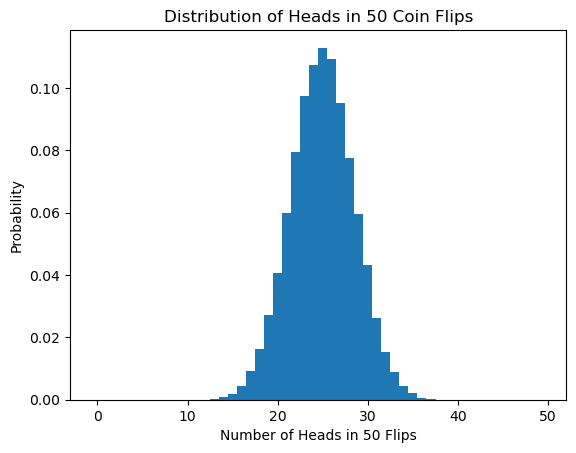

Probability of getting exactly 30 heads in 50 flips: 0.0431


In [27]:
def coinflip():
    return np.random.choice(['H', 'T'])

def flip_n_coins(n):
    return [coinflip() for _ in range(n)]

results = []
for i in range(0,100000):
    flips = flip_n_coins(50)
    head_count = flips.count('H')
    results.append(head_count)

plt.hist(results, bins=np.arange(0, 51) - 0.5, density=True)
plt.xlabel('Number of Heads in 50 Flips')
plt.ylabel('Probability')
plt.title('Distribution of Heads in 50 Coin Flips')
plt.show()

# Print the probability of getting 25 heads.
results = np.array(results)
prob_30_heads = np.mean(results == 30)
print(f"Probability of getting exactly 30 heads in 50 flips: {prob_30_heads:.4f}")

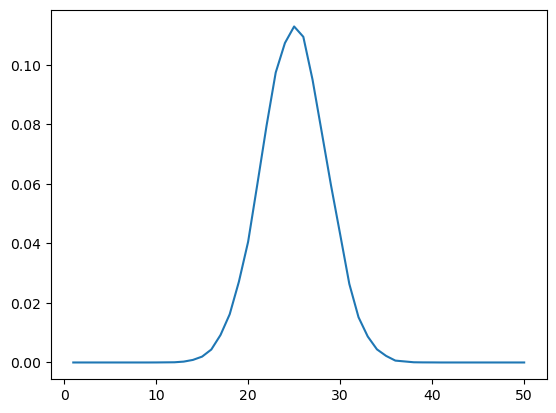

In [28]:
x = np.linspace(1,50,50)
y = np.array([np.mean(results == i) for i in x])

plt.plot(x,y)

In [42]:
def multiplicity(N,q):
    """
    Calculate the multiplicity of an einstein solid.
    N: number of oscillators
    q: number of energy units
    """
    from math import comb
    return comb(q + N - 1, q)

def print_multiplicity(N,q):
    mult = multiplicity(N,q)
    print(f"Multiplicity of an Einstein solid with N={N} oscillators and q={q} energy units is: {mult}")


from itertools import combinations_with_replacement

def print_einstein_microstates(n_oscillators, quanta):
    """
    Prints all microstates for an Einstein solid with 
    n_oscillators and total energy quanta.
    """
    # Create a list representing the oscillators, initially all with 0 energy
    oscillators = list(range(n_oscillators))
    
    # Microstates are combinations with replacement of quanta into oscillators
    # We use combinations_with_replacement to distribute 'quanta' units 
    # among 'n_oscillators'.
    microstates = list(combinations_with_replacement(range(n_oscillators), quanta))
    
    print(f"Einstein Solid: N={n_oscillators}, q={quanta}")
    print(f"Total Microstates: {len(microstates)}\n")
    print("Microstates (oscillator index receiving each quantum):")
    
    for i, state in enumerate(microstates):
        # Count how many quanta each oscillator has
        distribution = [0] * n_oscillators
        for osc_idx in state:
            distribution[osc_idx] += 1
        print(f"{i+1}: {distribution}")

# Example: 3 Oscillators (N=3), 3 Quanta (q=3)
supertotal = 0
for i in range(0,20):
    A=multiplicity(10,i)
    B=multiplicity(10,20-i)
    total = A*B
    supertotal = total+supertotal

supertotal


all_energy =multiplicity(10,10)*multiplicity(10,10)

all_energy/supertotal

0.12383242638651194

In [77]:
import itertools

def find_all_microstates_two_einstein_solids(N_A, N_B, q_total):
    """
    Finds all microstates for two interacting Einstein solids.

    N_A: Number of oscillators in solid A.
    N_B: Number of oscillators in solid B.
    q_total: Total number of energy quanta shared between the two solids.

    Returns:
        A dictionary where keys are macrostates (q_A, q_B) and values are 
        lists of microstates for that macrostate, represented as tuples.
    """
    all_microstates = {}
    
    # Iterate through all possible macrostates (all possible q_A values)
    for q_A in range(q_total + 1):
        q_B = q_total - q_A
        
        # Enumerate microstates for solid A
        microstates_A = []
        # Partitions q_A into N_A parts. Each part represents quanta in an oscillator.
        for p_A in itertools.product(range(q_A + 1), repeat=N_A):
            if sum(p_A) == q_A:
                microstates_A.append(p_A)

        # Enumerate microstates for solid B
        microstates_B = []
        # Partitions q_B into N_B parts.
        for p_B in itertools.product(range(q_B + 1), repeat=N_B):
            if sum(p_B) == q_B:
                microstates_B.append(p_B)
        
        # Combine microstates of A and B to get microstates of the composite system
        combined_microstates = []
        for mA in microstates_A:
            for mB in microstates_B:
                # Each microstate of the combined system is a tuple: (microstate_A, microstate_B)
                combined_microstates.append((mA, mB))
                
        if combined_microstates:
            all_microstates[(q_A, q_B)] = combined_microstates
            
    return all_microstates

# Example usage for small systems (large N or q will produce a massive list)
NA = 200
NB = 100
Q_total = 100

microstates_dict = find_all_microstates_two_einstein_solids(NA, NB, Q_total)

print(f"Total possible macrostates: {len(microstates_dict)}")
total_microstates_count = 0
for macrostate, microstates in microstates_dict.items():
    count = len(microstates)
    total_microstates_count += count
    print(f"Macrostate (q_A, q_B)={macrostate}: {count} microstates")

print(f"Total number of all microstates: {total_microstates_count}")

x=[]
y=[]
for i in microstates_dict.keys():
    #Also return info about qA and qB for each macrostate
    print(f"Macrostate (q_A, q_B)={i}: {len(microstates_dict[i])} microstates")
    print(f"Macrostate {i[0]}: {len(microstates_dict[i])} microstates")

    x.append(np.array(i[0]))
    y.append(len(microstates_dict[i]))

# make a histogram of the number of microstates for each macrostate
plt.bar(x,y)
plt.xlabel('Energy in Solid A (q_A)')
plt.ylabel('Number of Microstates')
plt.title('Microstates for Two Einstein Solids with Total Energy Q=100')
plt.show()

# find the most and least likely macrostates
most_likely_macrostate = max(microstates_dict, key=lambda k: len(microstates_dict[k]))
least_likely_macrostate = min(microstates_dict, key=lambda k: len(microstates_dict[k]))
# print the probabilities of the most and least likely macrostates
print(f"Most likely macrostate: {len(microstates_dict[most_likely_macrostate]) / total_microstates_count*100:.2f}% of {most_likely_macrostate} with {len(microstates_dict[most_likely_macrostate])} microstates")
print(f"Least likely macrostate: {len(microstates_dict[least_likely_macrostate]) / total_microstates_count*100:.2f}% of {least_likely_macrostate} with {len(microstates_dict[least_likely_macrostate])} microstates")
print(f"Probability of most likely macrostate: {len(microstates_dict[most_likely_macrostate]) / total_microstates_count:.4f}")
print(f"Probability of least likely macrostate: {len(microstates_dict[least_likely_macrostate]) / total_microstates_count:.4f}")

#make a pandas dataframe of each macrostate
macrostate_data = []
for macrostate, microstates in microstates_dict.items():
    q_A, q_B = macrostate
    count = len(microstates)
    probability = count / total_microstates_count
    macrostate_data.append({
        'q_A': q_A,
        'q_B': q_B,
        'microstate_count': count,
        'probability': probability
    })
df = pd.DataFrame(macrostate_data)
df

KeyboardInterrupt: 

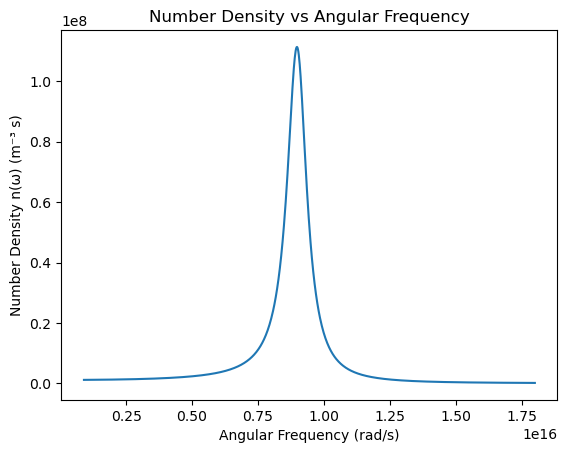

Peak of n(ω) is 1.11e+08 s / (rad m3) m⁻³ s at ω=8.98e+15 rad / s rad/s


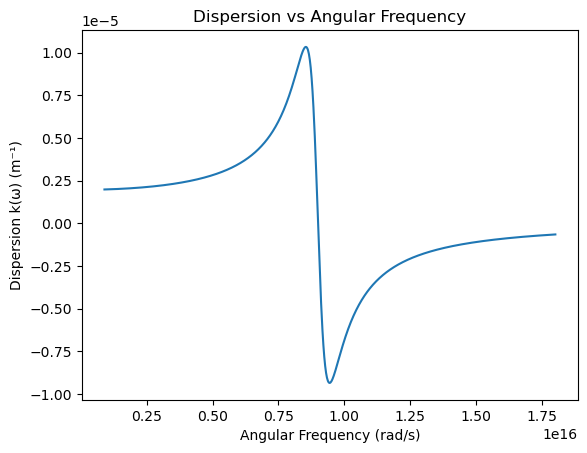

Peak of k(ω) is -9.35e-06 C2 s2 / (F kg m2 rad2) m⁻¹ at ω=9.44e+15 rad / s rad/s


In [9]:
numberdensity = 10**23 * (u.m**3)**-1
resonancefreq = 9*10**15 *(u.rad/u.s)
gamma = 0.1 * resonancefreq

#plot n(omega) vs omega from 0.1*resonancefreq to 2*resonancefreq
omega = np.linspace(0.1*resonancefreq, 2*resonancefreq, 1000)
n_omega = numberdensity * resonancefreq**2 * gamma / ( (resonancefreq**2 - omega**2)**2 + (gamma * omega    )**2 )
plt.plot(omega, n_omega)
plt.xlabel('Angular Frequency (rad/s)')
plt.ylabel('Number Density n(ω) (m⁻³ s)')
plt.title('Number Density vs Angular Frequency')
plt.show()
#print peak of n(omega)
peak_n_omega = np.max(n_omega)
peak_omega = omega[np.argmax(n_omega)]
print(f"Peak of n(ω) is {peak_n_omega:.2e} m⁻³ s at ω={peak_omega:.2e} rad/s")

#plot k(omega) vs omega from 0.1*resonancefreq to 2*resonancefreq
k_omega = (numberdensity * const.e.si**2) / (2 * const.eps0.si * const.m_e.si) * (resonancefreq**2 - omega**2) / ( (resonancefreq**2 - omega**2)**2 + (gamma * omega)**2 )
plt.plot(omega, k_omega)
plt.xlabel('Angular Frequency (rad/s)')
plt.ylabel('Dispersion k(ω) (m⁻¹)')
plt.title('Dispersion vs Angular Frequency')
plt.show()
peak_k_omega = np.min(k_omega)
peak_k_omega_omega = omega[np.argmin(k_omega)]
print(f"Peak of k(ω) is {peak_k_omega:.2e} m⁻¹ at ω={peak_k_omega_omega:.2e} rad/s")

In [ ]:
# calculate the amplitude and phase of the complex susceptibility at omega = omega0-2gamma, omega0, and omega0+2gamma
# Be careful with the values of the phase – both the values and signs of the real and imaginary part matter.
# Make sure units make sense for the amplitude and phase.
omega_values = [resonancefreq - 2*gamma, resonancefreq, resonancefreq + 2*gamma]
for omega in omega_values:
    chi_real = numberdensity * const.e.si**2 / (const.eps0.si * const.m_e.si) * (resonancefreq**2 - omega**2) / ( (resonancefreq**2 - omega**2)**2 + (gamma * omega)**2 )
    chi_imag = numberdensity * const.e.si**2 / (const.eps0.si * const.m_e.si) * (gamma * omega) / ( (resonancefreq**2 - omega**2)**2 + (gamma * omega)**2 )
    amplitude = np.sqrt(chi_real**2 + chi_imag**2)
    phase = np.arctan2(chi_imag, chi_real)
    print(f"At ω={omega:.2e}, Amplitude |χ|={amplitude:.2e}, Phase φ={phase:.4f} radians")
# for each frequency, calculate the phase between the polarization field and the electric field
# answers should be in terms of T=2pi/omega, the period of the driving electric field
for omega in omega_values:
    chi_real = numberdensity * const.e.si**2 / (const.eps0.si * const.m_e.si) * (resonancefreq**2 - omega**2) / ( (resonancefreq**2 - omega**2)**2 + (gamma * omega)**2 )
    chi_imag = numberdensity * const.e.si**2 / (const.eps0.si * const.m_e.si) * (gamma * omega) / ( (resonancefreq**2 - omega**2)**2 + (gamma * omega)**2 )
    phase = np.arctan2(chi_imag, chi_real)
    period = 2 * np.pi / omega
    print(f"At ω={omega:.2e}, Phase φ={phase} radians, which corresponds to {phase/(2*np.pi)*period} seconds delay relative to the electric field.")

# For each frequency, calculate the penetration depth and refractive index
e = const.e.si.value
eps0 = const.eps0.si.value
resonancefreq_val = resonancefreq.to(u.rad/u.s).value
gamma_val = gamma.to(u.rad/u.s).value
numberdensity_val = numberdensity.to((u.m**3)**-1).value
for omega in omega_values:
    omega_val = omega.to(u.rad/u.s).value
    chi_real = numberdensity_val * e**2 / (eps0 * const.m_e.si.value) * (resonancefreq_val**2 - omega_val**2) / ( (resonancefreq_val**2 - omega_val**2)**2 + (gamma_val * omega_val)**2 )
    chi_imag = numberdensity_val * e**2 / (eps0 * const.m_e.si.value) * (gamma_val * omega_val) / ( (resonancefreq_val**2 - omega_val**2)**2 + (gamma_val * omega_val)**2 )
    n_complex = np.sqrt(1 + chi_real + 1j*chi_imag)
    refractive_index = n_complex.real
    extinction_coefficient = n_complex.imag
    penetration_depth = 1 / (omega_val * extinction_coefficient / const.c.si.value)
    print(f"At ω={omega:.2e}, Refractive Index n={refractive_index}, Penetration Depth δ={penetration_depth:.4e} meters")



At ω=7.20e+15 rad / s, Amplitude |χ|=1.07e-05 C2 s2 / (F kg m2 rad2), Phase φ=0.2187 rad radians
At ω=9.00e+15 rad / s, Amplitude |χ|=3.93e-05 C2 s2 / (F kg m2 rad2), Phase φ=1.5708 rad radians
At ω=1.08e+16 rad / s, Amplitude |χ|=8.62e-06 C2 s2 / (F kg m2 rad2), Phase φ=2.8753 rad radians
At ω=7.20e+15 rad / s, Phase φ=0.218668945873942 rad radians, which corresponds to 3.037068692693639e-17 s seconds delay relative to the electric field.
At ω=9.00e+15 rad / s, Phase φ=1.5707963267948966 rad radians, which corresponds to 1.7453292519943295e-16 s seconds delay relative to the electric field.
At ω=1.08e+16 rad / s, Phase φ=2.875340604438868 rad radians, which corresponds to 2.6623524115174706e-16 s seconds delay relative to the electric field.
At ω=7.20e+15 rad / s, Refractive Index n=1.0000052003259599, Penetration Depth δ=3.6031e-02 meters
At ω=9.00e+15 rad / s, Refractive Index n=1.0000000001929772, Penetration Depth δ=1.6955e-03 meters
At ω=1.08e+16 rad / s, Refractive Index n=0.999

In [11]:
kappa = [0.08,1.24,0.24]
omega_values = [resonancefreq - 2*gamma, resonancefreq, resonancefreq + 2*gamma]
# for each kappa, calculate the penetration depth for the corresponding frequency
for i in range(len(kappa)):
    kappa_val = kappa[i]
    omega = omega_values[i]
    omega_val = omega.to(u.rad/u.s).value
    chi_real = numberdensity_val * e**2 / (eps0 * const.m_e.si.value) * (resonancefreq_val**2 - omega_val**2) / ( (resonancefreq_val**2 - omega_val**2)**2 + (gamma_val * omega_val)**2 )
    chi_imag = numberdensity_val * e**2 / (eps0 * const.m_e.si.value) * (gamma_val * omega_val) / ( (resonancefreq_val**2 - omega_val**2)**2 + (gamma_val * omega_val)**2 )
    n_complex = np.sqrt(1 + chi_real + 1j*chi_imag)
    refractive_index = n_complex.real
    extinction_coefficient = n_complex.imag
    penetration_depth = 1 / (omega_val * extinction_coefficient / const.c.si.value)
    print(f"For kappa={kappa_val}, at ω={omega:.2e}, Refractive Index n={refractive_index}, Penetration Depth δ={penetration_depth:.4e} meters")

For kappa=0.08, at ω=7.20e+15 rad / s, Refractive Index n=1.0000052003259599, Penetration Depth δ=3.6031e-02 meters
For kappa=1.24, at ω=9.00e+15 rad / s, Refractive Index n=1.0000000001929772, Penetration Depth δ=1.6955e-03 meters
For kappa=0.24, at ω=1.08e+16 rad / s, Refractive Index n=0.9999958441656899, Penetration Depth δ=2.4491e-02 meters


### Testing

In [41]:

#def wave_probability(psi,)
prob_array = []
k_size=[]
#for k in range(1,1000):
k=7
psi = lambda x: np.exp(-x**2)


def wave_prob(psi,bounds,x_range):

    """
    Finds the probability value of a wave function within the bounds.
    psi: Wave function that we wish to find the probability of.
    bounds: 2 Element list of upper and lower x-limits for evaluation.
    x_range: Defines the range of x values.
    """
    # 1. Define a wave function (e.g., Gaussian wave packet)
    lower,upper = bounds
    x = np.linspace(-x_range, x_range, 100*x_range)
    #psi = lambda x: np.exp(-x**2)#np.exp(-x**2)

    # 2. Normalize the wave function
    norm = np.sqrt(np.trapezoid(np.abs(psi(x))**2, x))
    psi_normalized = psi(x) / norm

    # 3. Calculate Probability Density |psi|^2
    probability_density = np.abs(psi_normalized)**2

    # 4. Find probability in a range (e.g., between -1 and 1)
    mask = (x > lower) & (x < upper)
    prob_in_range = np.trapezoid(probability_density[mask], x[mask])
    print(f"Probability in range: {prob_in_range:.4f}")
    return prob_in_range

wave_prob(psi,[-0.1,0.1],x_range=50)


Probability in range: 0.1429


np.float64(0.14285684543934454)

In [42]:
# Energy stored in a magnetic field:
# W = 0.5 * L * I**2
# W = 0.5*mu_0 * int(-inf,inf, B**2)*d_tau, which is in energy per unit volume.


# Example: A long coaxial cable carries current I (flows up on the inner cable, and down on the outer cable)
# -z direction on outer cable, +z direction on inner cable. Find the magnetic energy energy store in a segment of length l

# First calculate the magnetic field outside the coaxial cable. Assume radii a and b for the inner and outer cables. Segment l will be smaller than the original cable
# which we will assume extends to infinity.

# Expression of magnetic field between the two cylinders.
# This is due to Ampere's law.
B_ab = lambda s: const.mu0 * I / (2 * np.pi * s)

# We draw an Amperian Loop between the inner and outer cable to find the magnetic field between them. If we want to find the magnetic field of just the inner, ensure s<a. 
# For outside both cables, s>b

# We want to compute the inductance, which is:
# Phi = L * I
# Phi = int(-inf,inf, B)*da

# Intuitively, the magnetic energy should rely on the relationship between the two radii, where the magnetic energy should decrease as the difference between the two radii increases.
# Since the magnetic field when s<a and s>b, the bounds of our earlier integral become integration from a to b.

# The volume of the cylindrical shell of radius s, length l, and thickness ds is: volume of b - volume of a.
# V = l * np.pi * (s + ds)**2 - l * np.pi * s**2
# V = l * np.pi * 2 * ds * s = d_tau

# So our earlier integral becomes 
# W = 0.5 * const.mu0 * int of (B ** 2 * d_tau)
# W = const.mu0**2 * I**2 / 4 *np.pi**2 * int(1/s**2 * l * 2 * np.pi * s * ds)
# W = const.mu0**2 * I ** 2 * l / ( 2 * np.pi) * int_a_to_b(ds/s)

# Simplifying gives our final expression for the energy.
# W = const.mu0 * 0.5 * l / (2 * np.pi) * ln(b/a) * I**2
# Since this is in the same form as 0.5 * L * I**2, we can determine L.

# So the magnetic energy per unit volume between two coaxial cables carrying current I is:

def B_field_energy(W,L,I):
    return L * I ** 2 - W

3000 * u.J / ( 300 * u.A)

<Quantity 10. J / A>

In [ ]:
# Find the self-inductance of a toroidal coil with rectangular cross section. Total of N turns. Verify by calculating the energy.
# A toroid is a donut.
# The magnetic field B is given by:
# B = const.mu0*N*I/(2 * np.pi * s) * phi direction.
# The self-inductance is:
# Phi = L*I = int(B)*da

# Long story short, L = const.mu0 * N ** 2 * h / ( 2 * np.pi) * ln(b/a), where h is the height of the toroid, and a and b are the inner andn outer radii respectively. N is the number of turns.

#### Saha Equation

In [78]:
def Saha_Equation(temp,electron_pressure, charge1, charge2, ionization_energy):
    """
    Calculate the ratio of number densities of two ionization states using the Saha equation.

    Parameters:
    temp (float): Temperature in Kelvin.
    electron_pressure (float): Electron pressure in N/cm^2.
    charge1 (int): Charge of the lower ionization state.
    charge2 (int): Charge of the higher ionization state.
    ionization_energy (float): Ionization energy in eV.

    Returns:
    float: Ratio of number densities n2/n1.
    """
    # Convert ionization energy from eV to erg

    # Saha equation
    saha_const = (2 * np.pi * const.m_e * const.k_B * temp / const.h**2)**(3/2)
    exponent = -ionization_energy / (const.k_B.to(u.eV / u.K) * temp)
    ratio = saha_const * np.exp(exponent) * (2 * const.k_B * temp * charge1 / (charge2 * electron_pressure))
    return ratio.decompose()

In [79]:
electron_pressure = 20 * u.Newton / u.m**2
# Case 1: Helium at 5000 K

temp = 5000 * u.K
charge1 = 1
charge2 = 2
ionization_energy = 24.6 * u.eV
ratio = Saha_Equation(temp, electron_pressure, charge1, charge2, ionization_energy)
print(f"Ratio of number densities N2/N1 for He at 5000 K: {ratio:.3e}")


temp = 5000 * u.K
charge1 = 2
charge2 = 1
ionization_energy = 54.4 * u.eV
ratio = Saha_Equation(temp, electron_pressure, charge1, charge2, ionization_energy)
print(f"Ratio of number densities N3/N2 for He at 5000 K: {ratio:.3e}")

# Case 2: Helium at 15000 K

temp = 15000 * u.K
charge1 = 1
charge2 = 2
ionization_energy = 24.6 * u.eV
ratio = Saha_Equation(temp, electron_pressure, charge1, charge2, ionization_energy)
print(f"Ratio of number densities N2/N1 for He at 15000 K: {ratio:.3e}")


charge1 = 2
charge2 = 1
ionization_energy = 54.4 * u.eV
ratio = Saha_Equation(temp, electron_pressure, charge1, charge2, ionization_energy)
print(f"Ratio of number densities N3/N2 for He at 15000 K: {ratio:.3e}")

# Case 3: Helium at 25000 K

temp = 25000 * u.K
charge1 = 1
charge2 = 2
ionization_energy = 24.6 * u.eV
ratio = Saha_Equation(temp, electron_pressure, charge1, charge2, ionization_energy)
print(f"Ratio of number densities N2/N1 for He at 25000 K: {ratio:.3e}")


charge1 = 2
charge2 = 1
ionization_energy = 54.4 * u.eV
ratio = Saha_Equation(temp, electron_pressure, charge1, charge2, ionization_energy)
print(f"Ratio of number densities N3/N2 for He at 25000 K: {ratio:.3e}")


Ratio of number densities N2/N1 for He at 5000 K: 4.717e-19
Ratio of number densities N3/N2 for He at 5000 K: 1.732e-48
Ratio of number densities N2/N1 for He at 15000 K: 2.494e-01
Ratio of number densities N3/N2 for He at 15000 K: 9.696e-11
Ratio of number densities N2/N1 for He at 25000 K: 1.810e+03
Ratio of number densities N3/N2 for He at 25000 K: 7.116e-03


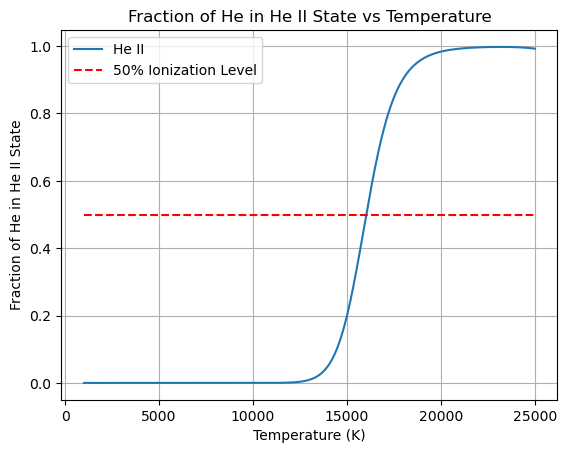

In [80]:
temprange = np.linspace(1000,25000,1000)
temp = temprange * u.K
charge1 = 1
charge2 = 2
ionization_energy = 24.6 * u.eV
n2_n1 = Saha_Equation(temp, electron_pressure, charge1, charge2, ionization_energy)

charge1 = 2
charge2 = 1
ionization_energy = 54.4 * u.eV
n3_n2 = Saha_Equation(temp, electron_pressure, charge1, charge2, ionization_energy)

n2_ntotal = n2_n1 / (1 + n2_n1 + n2_n1*n3_n2)
n2_ntotal

plottingarray = [temprange, n2_ntotal]

plt.plot(plottingarray[0], plottingarray[1], label='He II')
plt.hlines(0.5, color='r', linestyle='--', label = '50% Ionization Level',xmin=np.min(temprange), xmax=np.max(temprange))
plt.title('Fraction of He in He II State vs Temperature')
plt.xlabel('Temperature (K)')
plt.ylabel('Fraction of He in He II State')
plt.grid()
plt.legend()
plt.show()

#### Annoying Final Exam Question

In [ ]:
U_i = virial_theorem(E=0,M = 1.4 * u.M_sun, R = 1 * u.R_earth).to(u.J)
U_intermediate = virial_theorem(M = 1.4 * u.M_sun, R = 50 * u.km).to(u.J)
U_f = virial_theorem(M = 1.4 * u.M_sun, R = 12 * u.km).to(u.J)

NameError: name 'u' is not defined

In [36]:
del_u = U_intermediate - U_i
del_u
E_tot = 1.4 * u.M_sun * const.c**2
E_tot = E_tot.to(u.J)
E_f = E_tot + del_u
print(E_tot, E_f)

2.5019311362377908e+47 J 2.4711413356975917e+47 J


In [31]:
E_tot

<Quantity 2.50193114e+47 J>

In [6]:
### Method 1: Using only Virial Theoreom.

# Phase 1: Collapse from 1 Earth Radius to 50 km
M_i = 1.4 * u.M_sun
R_i = 1 * u.R_earth
R_f = 50 * u.km
U_i = virial_theorem(E=0,M = M_i, R = R_i).to(u.J)
E_tot_i = (1.4 * u.M_sun * const.c**2).to(u.J)
U_f = virial_theorem(E=0,M = M_i, R = R_f).to(u.J)
E_tot_f = E_tot_i - np.abs((U_f-U_i))
M_f = E_tot_f/const.c**2
print('Final mass after first collapse ' + str(M_f.to(u.M_sun)))

# Phase 2: Collapse from 50 km to 12 km.
M_i = M_f
R_i = R_f
R_f = 12 * u.km
U_i = virial_theorem(E=0, M = M_i, R = R_i).to(u.J)
E_tot_i = (1.4 * u.M_sun * const.c**2).to(u.J)
U_f = virial_theorem(E=0, M = M_i, R = R_f).to(u.J)
E_tot_f = E_tot_i - np.abs((U_f-U_i))
M_f = E_tot_f/const.c**2
M_f.to(u.M_sun)
print('Final mass after second collapse ' + str(M_f.to(u.M_sun)))


Final mass after first collapse 1.3827710203003036 solMass
Final mass after second collapse 1.3463556030574344 solMass


In [7]:
### Method 2: Using Virial theorem for initial collapse, then using free-fall timescale for second collapse.

# Phase 1: Collapse from 1 Earth Radius to 50 km.
M_i = 1.4 * u.M_sun
R_i = 1 * u.R_earth
R_f = 50 * u.km
U_i = virial_theorem(E=0,M = M_i, R = R_i).to(u.J)
E_tot_i = (1.4 * u.M_sun * const.c**2).to(u.J)
U_f = virial_theorem(E=0,M = M_i, R = R_f).to(u.J)
E_tot_f = E_tot_i - np.abs((U_f-U_i))
M_f = E_tot_f/const.c**2
M_f.to(u.M_sun)

# Phase 2: Collapse from 50 km to 12 km.
M_i = M_f
R_i = R_f 
R_f = 12 * u.km
rho = M_i / ( 4/3 * np.pi * R_i**3)
print(rho.to(u.kg/u.m**3))
T_ff = ((3 * np.pi ) / 32) * (1 / (const.G * rho) )**0.5
T_ff.to(u.s)

5251187882436432.0 kg / m3


<Quantity 0.0004975 s>

(array([ 18.,  99., 223., 148., 279., 147.,  46.,  33.,   6.,   1.]),
 array([15. , 16.7, 18.4, 20.1, 21.8, 23.5, 25.2, 26.9, 28.6, 30.3, 32. ]),
 <BarContainer object of 10 artists>)

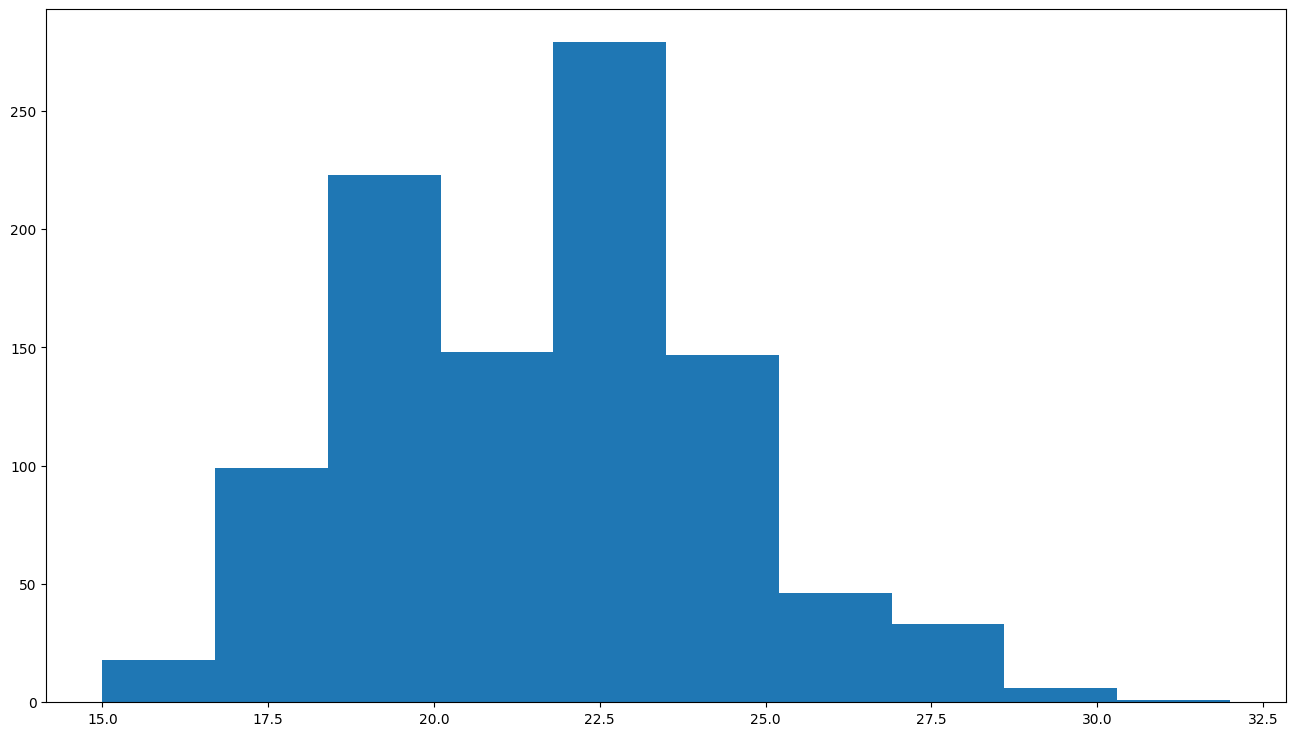

In [29]:
amount = 10000
amount_array = []
n = 1000
run_length_array = []
for i in range(n):
    amount = 10000
    amount_array = []
    while amount > 1:
        amount_array.append(amount)
        amount = amount - np.random.randint(1000)
        if amount < 0:
            amount = 0
            amount_array.append(amount)

    run_length_array.append(len(amount_array))
plt.figure(figsize=(16,9))
plt.hist(run_length_array)

### Hobby Stuff

In [242]:
def diceroll(value,multiple):
    result = []
    for i in range(multiple):
        result.append(np.random.randint(1,value+1))
    return result

def d4(multiple):
    return diceroll(4,multiple)

def d6(multiple):
    return diceroll(6,multiple)

def d8(multiple):
    return diceroll(8,multiple)

def d10(multiple):
    return diceroll(10,multiple)

def d12(multiple):
    return diceroll(12,multiple)

def d20(multiple):
    return diceroll(20,multiple)

def d100(multiple):
    return diceroll(100,multiple)

def statbonus(stat):
    return int((stat-10)/2)

class Character:
    def __init__(self, name, stats, max_hitpoint, current_hitpoint):
        self.name = name
        self.stats = stats
        self.max_hitpoint = max_hitpoint
        self.current_hitpoint = max_hitpoint

stat_array = np.array([['Strength','Dexterity','Constitution','Intelligence','Wisdom','Charisma'],[10,12,14,16,18,20]])
print(np.shape(stat_array))
Elrand = Character('Elrand',stats = stat_array, max_hitpoint=100, current_hitpoint=1)


class Weapon:
    def __init__(self,name,stat_name,hit_bonus,damage_bonus,crit_range = 20,damage_die = lambda: d8(3), damage_type = 'Force'):
        self.name = name
        self.stat_name = stat_name
        self.hit_bonus = hit_bonus
        self.damage_bonus = damage_bonus
        self.damage_die = damage_die
        self.damage_type = damage_type
        self.crit_range = crit_range 
        self.crit = False

    def attack(self,Character,adv = False, dis = False):
        stat = Character.stats[Character.stats[:,0]==self.stat_name][:,1].astype(float).item()
        self.crit = False
        if not adv ^ dis:
            roll = d20(1)[0]
            if roll >= self.crit_range:
                print('Crit!')
                self.crit = True
            return roll + self.hit_bonus + statbonus(stat)

        elif adv == True:
            roll = np.max(d20(2))
            if roll >= self.crit_range:
                print('Crit!')
                self.crit = True
            return int(roll + self.hit_bonus + statbonus(stat))
        
        elif dis == True:
            roll = np.min(d20(2))
            if roll >= self.crit_range:
                print('Crit!')
                self.crit = True
            return int(roll + self.hit_bonus + statbonus(stat))
    
    def damage(self):
        multiplier = 1
        if self.crit == True:
            multiplier = 2
        return int(multiplier * (np.sum(self.damage_die()) + self.damage_bonus))
        

    


stat_array = np.array([['Strength','Dexterity','Constitution','Intelligence','Wisdom','Charisma'],[10,12,14,16,18,20]]).T

Elrand = Character('Elrand',stats = stat_array, max_hitpoint=100, current_hitpoint=1)

bow = Weapon('Branch of Life','Dexterity',4,4,15,lambda: d8(3),'Force')
bow.attack(Elrand, adv = True)
bow.damage()

(2, 6)


25

In [251]:
bow.attack(Elrand, adv = True)
bow.damage()

Crit!


24

### Astro Problems

In [4]:
SiriusA_M = 2.3 * u.M_sun
SiriusB_M = 1.053 * u.M_sun
period = 49.9 * u.yr
binary_separation = 10 * u.arcsec
binary_parallax = 0.379 * u.arcsec
binary_distance = arcsec_to_parsec(binary_parallax)
SiriusA_L = 23.5 * u.L_sun
SiriusB_L = 0.03 * u.L_sun

# Using spectroscopy with Wein's Displacement Law, it was determined that Sirius A and B have effective temperatures of
SiriusA_Teff = 9910 * u.K
SiriusB_Teff = 27000 * u.K

# Then, using S-B, we can calculate the radius of each.
SiriusA_R = solve_quantity(StefanBoltzmann,L=SiriusA_L,Teff=SiriusA_Teff, R = None, bracket=(1000,1e15) * u.m)
print(SiriusA_R)
SiriusB_R = solve_quantity(StefanBoltzmann,L=SiriusB_L,Teff=SiriusB_Teff, R = None, bracket=(1000,1e15) * u.m)
print(SiriusB_R)


# We can calculate the density using these values.
SiriusA_Volume = spherical_volume(SiriusA_R)
SiriusA_rho = (SiriusA_M/SiriusA_Volume).to(u.kg / u.m**3)
print(SiriusA_rho)

SiriusB_Volume = spherical_volume(SiriusB_R)
SiriusB_rho = (SiriusB_M / SiriusB_Volume).to(u.kg / u.m**3)
print(SiriusB_rho)

# As well as the gravity on the surface of each star.
SiriusA_g = grav_accel(g = 0, M = SiriusA_M.to(u.kg), r = SiriusA_R)
SiriusB_g = grav_accel(g = 0, M = SiriusB_M.to(u.kg), r = SiriusB_R)
print(SiriusA_g)
print(SiriusB_g)

1144094206.4304976 m
5506913.606792613 m
729.0541356820942 kg / m3
2993097625.847232 kg / m3
233.19320814939226 m / s2
4608116.8025627 m / s2


In [ ]:
# Three star system in 40 Eridani. 40 Eri A, 40 Eri B, 40 Eri C.
period_b_c = 228.12 * u.yr
trig_parallax = 0.201 * u.arcsec
# Angular extent of reduced mass is
angular_semimajor_axis_length = 6.89 * u.arcsec
# Ratio of distance from center of mass for ab / ac is 
semimajor_axis_ratio = 0.37

#mass ratio is inversely proportional to the radius ratios. So the mass ratio of mb/mc
mass_ratio = 1/semimajor_axis_ratio
# Find mass of B and C in terms of solar masses.

distance_to_BC = arcsec_to_parsec(trig_parallax)
semimajor_axis_length = (angular_semimajor_axis_length / trig_parallax) * u.AU

# Using the true semimajor axis length of the reduced mass, along with the period, we can find the reduced mass of the system.
tot_mass = solve_quantity(Kepler3_totMass, P = period_b_c,M=None,a=semimajor_axis_length,bracket = (1e20,1e35) * u.kg)

#red_mass = 1/red_mass * 1 * u.M_sun ** 2

tot_mass.to(u.M_sun)
mass_ratio = massC/massB



<Quantity 0.77403246 solMass>

In [19]:
B_mass_expected = 0.57 * u.M_sun
C_mass_expected = 0.204 * u.M_sun

B_mass_expected * C_mass_expected / (B_mass_expected+C_mass_expected)

tot_mass_expected=(B_mass_expected+C_mass_expected)
tot_mass_expected.to(u.M_sun)

<Quantity 0.774 solMass>

In [12]:
tot_mass_expected = solve_quantity(Kepler3_totMass, P = None,M=(B_mass_expected+C_mass_expected),a=semimajor_axis_length,bracket = (50,1e20) * u.s)
tot_mass_expected.to(u.yr)


<Quantity 228.12478302 yr>

#### Astro 24.3

In [6]:
# The globular cluster IAU C0923−545 has an integrated apparent visual magnitude of V =
# +13.0 and an integrated absolute visual magnitude of MV = −4.15. It is located 9.0 kpc from
# Earth and is 11.9 kpc from the Galactic center, just 0.5 kpc south of the Galactic midplane.
# (a) Estimate the amount of interstellar extinction between IAU C0923−545 and Earth.
# (b) What is the amount of interstellar extinction per kiloparsec?

apparent_mag = 13
absolute_mag = -4.15
distance_to_Earth = 9 * u.kpc
distance_to_GalCen = 11.9 * u.kpc

extinction=solve_quantity(distance_modulus_extinction,M=absolute_mag,m=apparent_mag,d=distance_to_Earth,k=None, bracket = (0,1e3) * (1/u.kpc))
extinction

<Quantity 0.26430972 1 / kpc>

#### Astro 24.4

In [ ]:
# Using the differential star count formula for an infinite universe of constant stellar number
# density and no interstellar extinction (Eq. 24.5), show that the amount of light arriving at Earth
# from a cone of solid angle Omega diverges exponentially as the length of the cone increases without
# bound (or, equivalently, as m approaches infinity). Assume that all stars in the field have the
# same absolute magnitude M . Hint: You may find the discussion leading up to Eq. (3.5) helpful